<a href="https://colab.research.google.com/github/stefanogiagu/corso_AI_2026/blob/main/MetodiAI_2026_E10_GNN_RICH_torch_geometric.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Metodi AI per La Fisica 2026

## Esercitazione E9: allenamento end-to-end di una semplice GNN per la classificazione di eventi in un rivelatore RICH in fisica delle particelle

Faccimao il minimo necessario di cambiamenti per lavorare su una GNN!




**Identificazione di particelle con rivelatori RICH**

**Task**: stimare il numero di particelle cariche e il numero di elettroni per ogni evento ricostruito con il rivelatore RICH dell'esperimento NA62 al CERN.

Descrizione del rivelatore RICH: [link](https://na62.web.cern.ch/DetectorBeam/RICH.html)

Il rivelatore RICH (Ring Imaging CHerenkov) dell’esperimento NA62 è progettato per identificare particelle cariche misurando la radiazione Čerenkov emessa quando attraversano un mezzo. Quando una particella carica attraversa il gas con velocità maggiore della velocità della luce nel mezzo, emette radiazione Čerenkov sotto forma di un cono di luce. Questo cono, proiettato sul piano dei rivelatori di luce, genera un anello luminoso. Il goal è identificare il numero di anelli presenti nel rivelatore.

**Input originale:** i dati del rivelatore RICH sono rappresentati come immagini di shape $[N,16,16]$, in cui ogni pixel indica il numero di hit misurati dai PMT in una certa zona geometrica del rivelatore. Gli eventi possono avere 0,1,2 e 3+ anelli. Le label di classe sono date in un vettore numpy di label in formato one-hot.

**Input per la GNN:** in questo notebook trasformiamo ogni immagine in un grafo. I nodi sono solo i pixel con hit non nullo. La feature del nodo contiene l'intensità dell'hit e la posizione normalizzata/scalata; la posizione geometrica non normalizzata è salvata in `data.pos`. Gli archi sono costruiti collegando ogni hit ai suoi $k=4$ vicini più prossimi nello spazio $(riga, colonna)$. Usiamo `torch_geometric` e una GNN semplice basata su `SAGEConv`.

Lo scopo è didattico: confrontare direttamente una CNN che lavora su una griglia regolare con una GNN che lavora su una rappresentazione sparsa a grafo degli stessi eventi.


In [1]:
# crea il folder data e download il dataset
import os

success = os.path.exists("data")
if not success:
  os.makedirs("data")

success = os.path.exists("data/x_all_08011.npy")
if not success:
  !wget http://giagu.web.cern.ch/giagu/CERN/x_all_08011.npy -P data/
  !wget http://giagu.web.cern.ch/giagu/CERN/y_all_08011.npy -P data/

In [2]:
!ls -lh  data/

total 40M
-rw-r--r-- 1 root root  40M May  3 15:07 x_all_08011.npy
-rw-r--r-- 1 root root 626K May  3 15:06 y_all_08011.npy


**Leggiamo i dati, controlliamo il formato (shape), e plottiamo un esempio di immagine**

*   i dati sono in formato numpy, possono essere letti con la funzione *np.load*
*   printiamo la shape dei vettori numpy letti e il tipo di variabile
*   usiamo matplotlib *plt.imshow()* o *plt.matshow* per plottare un elemento dell array



In [3]:
import numpy as np


x_all = np.load('data/x_all_08011.npy')
y_all = np.load('data/y_all_08011.npy')

print('Shape immagini: ',x_all.shape)
print('Shape label: ',y_all.shape)
print('Tipo immagini: ', x_all.dtype)
print('Tipo label: ', y_all.dtype)

Shape immagini:  (20000, 16, 16)
Shape label:  (20000, 4)
Tipo immagini:  float64
Tipo label:  float64


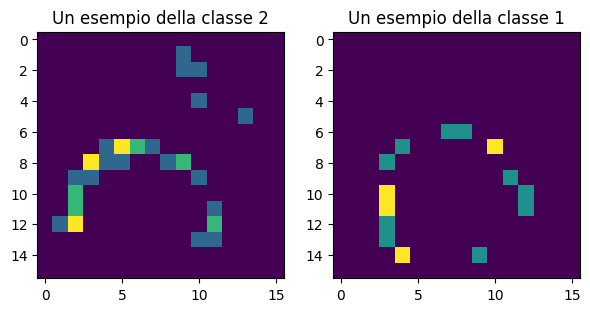

In [4]:
import matplotlib.pyplot as plt

# plottiamo due immagini idx=0 e idx=10
idx1 = 0
idx2 = 10
plt.figure(figsize=(7,5))
plt.subplot(1,2,1)
plt.imshow(x_all[idx1,:,:])
plt.title("Un esempio della classe {}".format(np.argmax(y_all[idx1])))
plt.subplot(1,2,2)
plt.imshow(x_all[idx2,:,:])
plt.title("Un esempio della classe {}".format(np.argmax(y_all[idx2])))
plt.show()

**Analisi delle immagini**

plottiamo l'istogramma dell'intensità media per classe delle immagini. Costruiamo una funzione atta allo scopo

deve essere [N,1] :  (20000,)


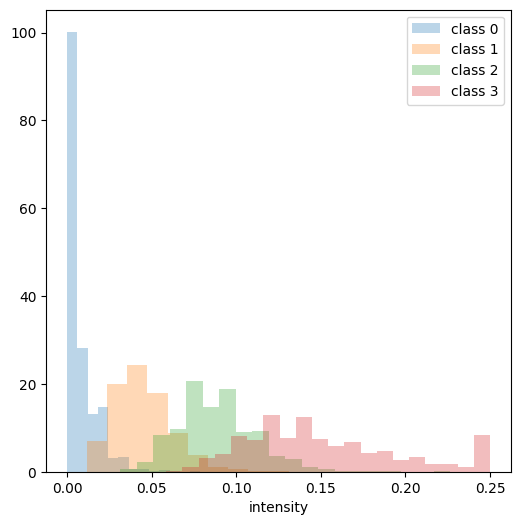

In [5]:
def plot_histointensity(x, y):

  classes = np.argmax(y, axis=1) #ritorna l'indice del massimo valore di un array lungo la dimensione axis

  intensities = x.reshape(x.shape[0],-1).mean(axis=1) # [N,16,16] -> [N,16*16] e poi fa la media lungo la dimensione axis (axis=1 -> secnodna dimensione)
  print("deve essere [N,1] : ",intensities.shape)

  f,ax = plt.subplots(1,1,figsize=(6,6))
  for c in [0,1,2,3]:
    ax.hist(intensities[classes==c],20,alpha=0.3,label="class {}".format(c),density=True)

  ax.set_xlabel("intensity")
  ax.legend()

plot_histointensity(x_all, y_all)

deve essere [N,1] :  (18402,)


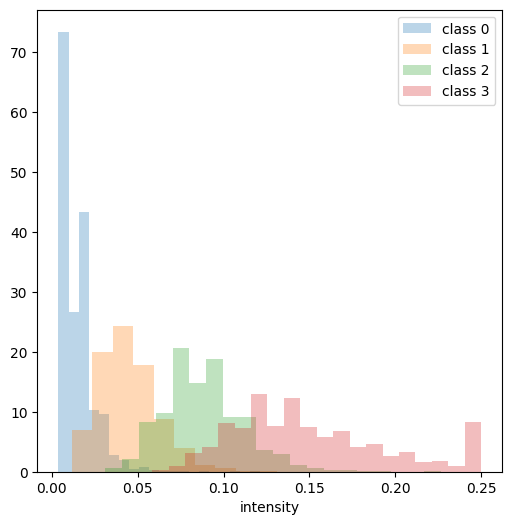

In [6]:
# rimuoviamo le immagini totalmente vuote (non sono utili, qualsiasi operazione su un array di zeri è banale, inoltre già sappiamo che nessun segnale significa nessuna particella

def remove_empty(x, y):
  intensities = x.reshape(x.shape[0],-1).sum(axis=1)
  y_tmp = y[intensities>0]
  x_tmp = x[intensities>0]
  return x_tmp, y_tmp

x_all, y_all = remove_empty(x_all, y_all)
plot_histointensity(x_all, y_all)

**Analisi delle immagini**

plottiamo la distribuzione delle classi son un istogramma a torta

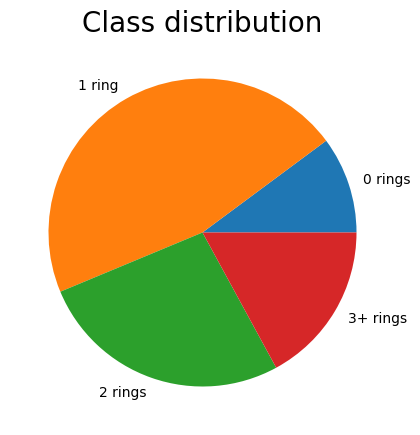

In [7]:
# definiamo la finzione piechartclasses

def piechartclasses(y):
  classes = np.argmax(y, axis=1)
  c = np.unique(classes) #ritorna gli elementi unici di un array (ordinati)
  arr_c = [np.mean(classes==i) for i in c]


  fig = plt.figure(figsize =(8, 5))
  plt.pie(arr_c, labels = ["0 rings", "1 ring", "2 rings", "3+ rings"])
  plt.title("Class distribution",fontsize=20)
  plt.show()

piechartclasses(y_all)

**Convertiamo i dati in grafi torch-geometric, creiamo dataset e dataloader e facciamo data-augmentation**

Rispetto al notebook CNN, la differenza principale è questa: invece di restituire un tensore immagine `(1,16,16)`, il dataset restituisce un oggetto `torch_geometric.data.Data` con nodi, archi, feature, posizioni e label.


In [8]:
import sys
import subprocess
import importlib.util

# Cambiamento rispetto alla CNN: serve torch_geometric per rappresentare eventi come grafi e per usare il DataLoader di PyG.
#
if importlib.util.find_spec("torch_geometric") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "torch-geometric"])

from torch.utils.data import Dataset
import torch
import torch.utils.data as data
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

# data augmentation: manteniamo le stesse trasformazioni del notebook CNN, perché vogliamo cambiare solo la rappresentazione dei dati.

# rimozione di un hit
def remove_a_hit(image):
  if image.sum()<3:
    return image
  a,b = np.nonzero(image) # ritorna due vettori (uno per ogni dimensione) corrispondenti agli elementi non zero
  i = np.random.randint(0,len(a))
  image[a[i],b[i]] -=1
  return image

# aggiunge un hit
def add_a_hit(image):
  image[np.random.randint(0,16),np.random.randint(0,16)] +=1
  return image

# flip tutti gli hit
def flip_hit(image):
  if np.random.rand()>0.5:
    image= np.fliplr(image) #rovescia l'ordine degli elementi lungo left-right
  else:
    image= np.flipud(image)  #rovescia l'ordine degli elementi lungo up-down
  return image

# sovrappone due immagini
def sum_images(image,lab,image2,lab2):
  lab=np.argmax(lab)
  lab2=np.argmax(lab2)
  image = image + image2
  lab = lab + lab2
  if lab>3:
    lab=3
  lab_tmp = np.zeros(4)
  lab_tmp[lab]=1

  return image,lab_tmp


def build_knn_edges(pos, k=4):
    """Costruisce edge_index in formato PyG usando i k vicini più prossimi.

    Cambiamento rispetto alla CNN: il vicinato locale non è più definito da kernel convoluzionali su griglia,
    ma da archi tra hit vicini nello spazio del rivelatore. Usiamo archi diretti nel formato standard PyG.
    """
    num_nodes = pos.size(0)
    if num_nodes <= 1:
        return torch.empty((2, 0), dtype=torch.long)

    k_eff = min(k, num_nodes - 1)
    dist = torch.cdist(pos, pos)
    dist.fill_diagonal_(float("inf"))
    nn_index = dist.topk(k_eff, largest=False).indices  # [num_nodes, k_eff]

    # edge_index[0] = sorgente, edge_index[1] = destinazione.
    # Per ogni nodo destinazione, i sorgenti sono i suoi k vicini più prossimi.
    row = nn_index.reshape(-1)
    col = torch.arange(num_nodes).repeat_interleave(k_eff)
    edge_index = torch.stack([row, col], dim=0).long()
    return edge_index


# creiamo una Dataset in torch. In questo esempio non usiamo i torch  Dataset usati negli esempi precedenti perché vogliamo
# applicare alcune trasformazioni "custom" ai dati, utili per l'addestramento.

# lo scopo del data Generator è quello di generare minibatch + fare data augmentation

class HitGraphGenerator(Dataset): # Cambiamento rispetto alla CNN: il Dataset ora produce grafi PyG, non immagini.
    def __init__(self, X, y, AUGMENT=False, k=4):
        self.X = X
        self.y = y
        self.AUGMENT = AUGMENT
        self.k = k

    def __len__(self): #ritorna la dimensione del dataset
        return len(self.X)

    def __getitem__(self, idx): #ritorna l'elemento idx del dataset
        image = self.X[idx].copy() # copiamo per evitare che la data augmentation modifichi l'array originale
        label = self.y[idx].copy()
        iclass = np.argmax(label)

        if self.AUGMENT: # applica data augmentation (da usare solo in training)
          if iclass >1:
            if np.random.rand()>1:  # >1 per disabilitare questa augmentation che non è molto utile nel nostro caso
              image = remove_a_hit(image)
          if np.random.rand()>1:    # >1 per disabilitare questa augmentation che non è molto utile nel nostro caso
            image = add_a_hit(image)
          if np.random.rand()>0.5:  # questa è utile
            image = flip_hit(image)
          if np.random.rand()>0.85: # anche questa è utile
            id2=np.random.randint(len(self.X))
            image2 = self.X[id2]
            lab2 = self.y[id2]
            image, label = sum_images(image,label,image2,lab2)

        # Cambiamento rispetto alla CNN: teniamo solo gli hit non nulli come nodi del grafo.
        rows, cols = np.nonzero(image)
        values = image[rows, cols].astype(np.float32)

        # data.pos contiene le coordinate geometriche non normalizzate degli hit sul piano 16x16.
        pos = torch.tensor(np.stack([rows, cols], axis=1), dtype=torch.float)

        # data.x contiene le feature dei nodi: intensità normalizzata + coordinate normalizzate e scalate in [-1, 1].
        # Questo mantiene l'informazione locale usata dalla CNN, ma in forma tabulare per ogni nodo.
        intensity = torch.tensor(values / image.sum(), dtype=torch.float).view(-1, 1)
        pos_scaled = (pos / 15.0) * 2.0 - 1.0 # valuta di normalizzare sul centro di massa
        x = torch.cat([intensity, pos_scaled], dim=1)

        # Il grafo è costruito con k=4 vicini più prossimi degli hit.
        edge_index = build_knn_edges(pos, k=self.k)

        # Manteniamo la label one-hot come nel notebook CNN; PyG concatenerà queste righe nella batch.
        tensor_label = torch.from_numpy(label).float().view(1, -1)

        return Data(x=x, edge_index=edge_index, y=tensor_label, pos=pos)


# costruiamo anche un DataLoader custom, che permetta di bilanciare le classi facendo un oversampling delle classi minoritarie in modo da evitare bias nell'addestramento
# del modello (se una classe e' preponderante il modello può non imparare bene e cercare di predire in modo naive solo la classe maggioritaria)

# NOTA: rispetto al notebook CNN ereditiamo dal DataLoader di torch_geometric, non da quello standard di PyTorch,
# perché il collate di PyG sa unire molti grafi in un singolo oggetto Batch con componenti sconnesse.

class BalancedDataLoader(DataLoader):
    def __init__(self, dataset, batch_size=1, shuffle=True):
        self.dataset = dataset
        self.batch_size = batch_size
        self.shuffle = shuffle

        # conta il numero di eventi in ciascuna classe
        class_counts = torch.bincount(torch.tensor(np.argmax(dataset.y,axis=1)))

        # calcola il peso di ciascun evento (1/frazione della classe nel dataset)
        weights = 1.0 / class_counts[np.argmax(dataset.y, axis=1)] # ha la stessa lunghezza del array dei dati

        # crea un campionatore che campiona ogni classe con eguale probabilità
        sampler = torch.utils.data.sampler.WeightedRandomSampler(weights, len(weights))

        super().__init__(dataset, batch_size=batch_size, sampler=sampler)


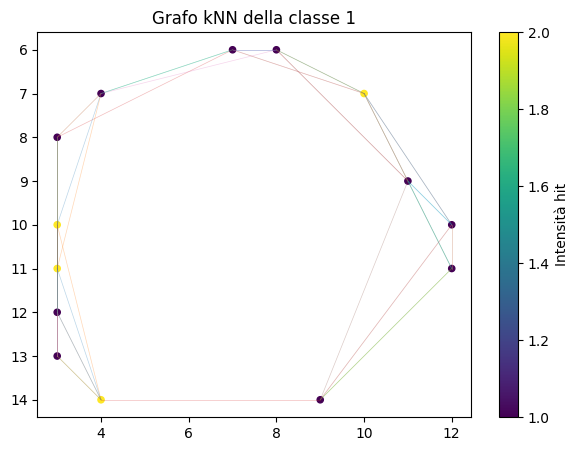

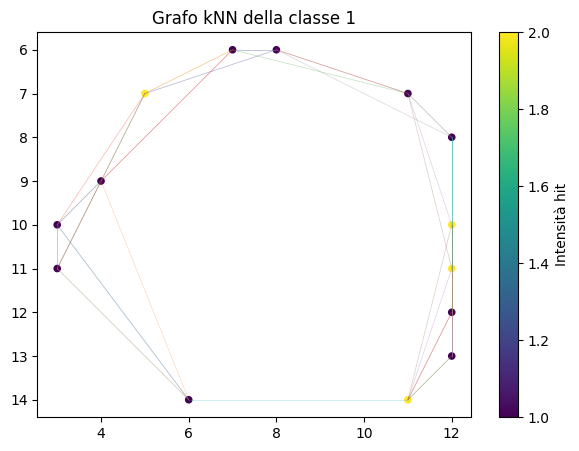

In [9]:
# Plottiamo un esempio di data augmentation.
# Cambiamento rispetto alla CNN: mostriamo il grafo costruito dagli hit non nulli,

def build_knn_edges(pos, k=4):
    """
    Costruisce edge_index nel formato PyG [2, num_edges] usando solo PyTorch.

    pos:
      array NumPy oppure tensore PyTorch con shape [num_nodes, 2]

    Output:
      edge_index:
        tensore torch.long con shape [2, num_edges]
    """

    pos = torch.as_tensor(pos, dtype=torch.float)

    num_nodes = pos.shape[0]

    if num_nodes == 0:
        return torch.empty((2, 0), dtype=torch.long)

    # Se ci sono pochi nodi, k non può superare num_nodes - 1.
    k_eff = min(k, num_nodes - 1)

    if k_eff == 0:
        return torch.empty((2, 0), dtype=torch.long)

    # Matrice delle distanze euclidee tra tutti i nodi.
    dist = torch.cdist(pos, pos)

    # Evitiamo che un nodo scelga sé stesso come vicino.
    dist.fill_diagonal_(float("inf"))

    # Per ogni nodo, prendiamo i k vicini più prossimi.
    knn = dist.topk(k=k_eff, largest=False).indices

    # Formato PyG: edge_index[0] = sorgenti, edge_index[1] = destinazioni.
    src = torch.arange(num_nodes).repeat_interleave(k_eff)
    dst = knn.reshape(-1)

    edge_index = torch.stack([src, dst], dim=0)

    return edge_index


def image_to_graph_for_plot(image, k=4):
    """
    Converte un'immagine RICH in un grafo kNN per la sola visualizzazione.

    Nodi:
      - solo pixel/hit non nulli

    Feature:
      - intensità del pixel

    Posizione:
      - coordinate non normalizzate, usate per costruire e plottare il grafo
    """

    hit_y, hit_x = np.nonzero(image)

    pos = np.stack([hit_x, hit_y], axis=1).astype(np.float32)
    intensity = image[hit_y, hit_x].astype(np.float32)

    edge_index = build_knn_edges(pos, k=k)

    return pos, intensity, edge_index


def plot_graph_from_image(image, lab, k=4):
    pos, intensity, edge_index = image_to_graph_for_plot(image, k=k)

    plt.figure(figsize=(7, 5))

    if pos.shape[0] == 0:
        plt.title("Nessun hit non nullo nella classe {}".format(np.argmax(lab)))
        plt.axis("off")
        plt.show()
        return

    # Disegno gli archi del grafo kNN.
    for src, dst in edge_index.t().numpy():
        plt.plot(
            [pos[src, 0], pos[dst, 0]],
            [pos[src, 1], pos[dst, 1]],
            linewidth=0.5,
            alpha=0.3
        )

    # Disegno i nodi. Il colore rappresenta l'intensità dell'hit.
    plt.scatter(
        pos[:, 0],
        pos[:, 1],
        c=intensity,
        s=20,
        cmap="viridis"
    )

    plt.gca().invert_yaxis()
    plt.axis("equal")
    plt.colorbar(label="Intensità hit")
    plt.title("Grafo kNN della classe {}".format(np.argmax(lab)))
    plt.show()


image = x_all[10, :, :]
lab = y_all[10]

plot_graph_from_image(image, lab, k=4)
plot_graph_from_image(flip_hit(image), lab, k=4)

In [10]:
# splittiamo ora il dataset e creiamo i dataset e dataloader

from sklearn.model_selection import train_test_split
X, X_test, y, y_test = train_test_split(x_all, y_all, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Cambiamento rispetto alla CNN: il Dataset produce oggetti Data di torch_geometric.
train_dataset = HitGraphGenerator(X_train, y_train, AUGMENT=True, k=4)
train_loader = BalancedDataLoader(train_dataset, batch_size=256, shuffle=True)

val_dataset = HitGraphGenerator(X_val,y_val, k=4)
val_loader = BalancedDataLoader(val_dataset, batch_size=256, shuffle=False)

test_dataset = HitGraphGenerator(X_test,y_test, k=4)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False) #non usiamo il balanced generator per il test. (evita leaks dal training set)


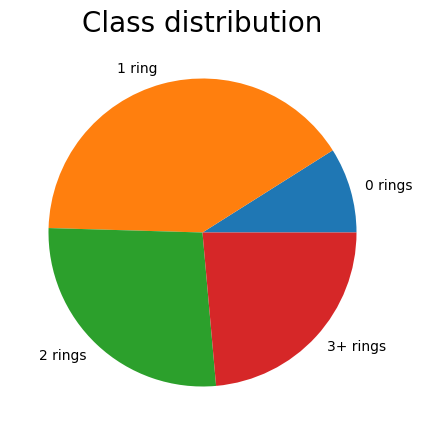

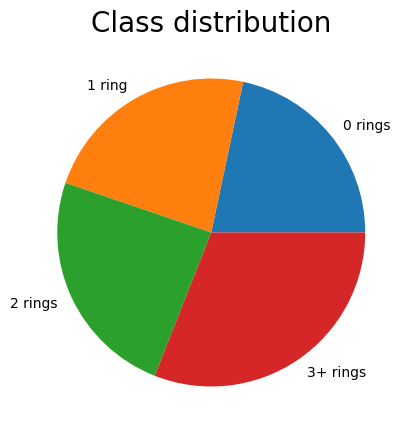

In [11]:
# controlliamo che il balancing stia funzionando

balanced  =[]
notbalanced=[]
tmp_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Cambiamento rispetto alla CNN: il loader restituisce una Batch PyG; le label sono in batch.y.
for batch in train_loader:
  balanced.extend(batch.y.numpy())
for batch in tmp_loader:
  notbalanced.extend(batch.y.numpy())

piechartclasses(notbalanced)    #con dataloader non bilanciato
piechartclasses(balanced)       #con dataloader bilanciato


Numero di grafi nella batch: 8
Numero totale di nodi nella batch: 166
Numero totale di archi nella batch: 660
Archi tra componenti diverse: 0


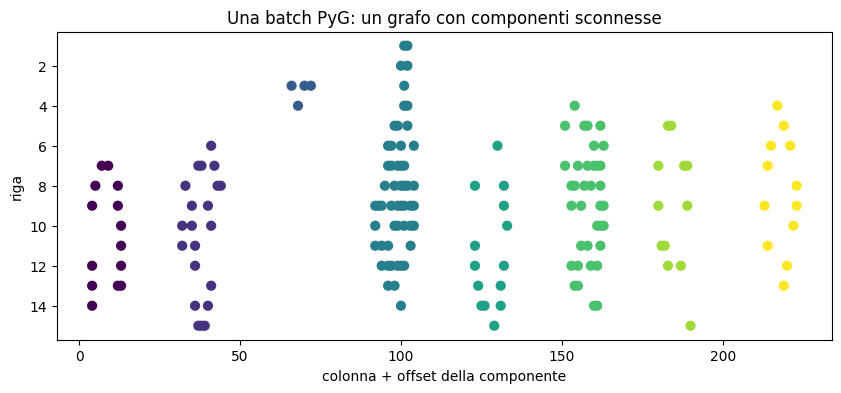

In [12]:
# Visualizziamo una batch PyG: una batch è un unico grafo con componenti sconnesse.
# Ogni componente corrisponde a un evento RICH; batch.batch indica a quale evento appartiene ogni nodo.

batch_example = next(iter(DataLoader(train_dataset, batch_size=8, shuffle=True)))

edge_index = batch_example.edge_index
src_component = batch_example.batch[edge_index[0]]
dst_component = batch_example.batch[edge_index[1]]
print("Numero di grafi nella batch:", batch_example.num_graphs)
print("Numero totale di nodi nella batch:", batch_example.num_nodes)
print("Numero totale di archi nella batch:", batch_example.num_edges)
print("Archi tra componenti diverse:", int((src_component != dst_component).sum()))

# Per rendere visibili le componenti, applichiamo solo nel plot un offset orizzontale diverso a ogni grafo.
pos = batch_example.pos.numpy()
component = batch_example.batch.numpy()

plt.figure(figsize=(10,4))
plt.scatter(pos[:,1] + 30*component, pos[:,0], c=component, s=40)
plt.gca().invert_yaxis()
plt.xlabel("colonna + offset della componente")
plt.ylabel("riga")
plt.title("Una batch PyG: un grafo con componenti sconnesse")
plt.show()


**Modello Graph Neural Network**

Implementiamo una GNN semplice basata su `SAGEConv`. La parte convoluzionale della CNN è sostituita da message passing sul grafo;


In [13]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv, global_mean_pool


class Net(nn.Module):
    def __init__(self):
        super().__init__()

        # Cambiamento rispetto alla CNN: SAGEConv lavora su nodi e archi, non su pixel ordinati in una griglia.
        # Ogni nodo ha 3 feature: intensità normalizzata, riga normalizzata/scalata, colonna normalizzata/scalata.
        self.conv1 = SAGEConv(3, 32)
        self.conv2 = SAGEConv(32, 64)
        self.conv3 = SAGEConv(64, 64)

        # Dopo il message passing, global_mean_pool aggrega i nodi di ogni grafo in un embedding di evento.
        self.fc1 = nn.Linear(64, 64)
        self.fc2 = nn.Linear(64, 64)
        self.dropout1 = nn.Dropout(p=0.3)
        self.fc3 = nn.Linear(64,4)

    def forward(self, data):
       x, edge_index, batch = data.x, data.edge_index, data.batch

       x = F.relu(self.conv1(x, edge_index))
       x = F.relu(self.conv2(x, edge_index))
       x = F.relu(self.conv3(x, edge_index))

       # Cambiamento rispetto alla CNN: torch.flatten è sostituito da un pooling globale sui nodi del grafo.
       x = global_mean_pool(x, batch)

       x = F.relu(self.fc1(x))
       x = self.dropout1(x)
       x = F.relu(self.fc2(x))
       x = self.dropout1(x)
       x = self.fc3(x)        # non serve applicare softmax in uscita perché in pytorch lo fa automaticamente la crossentropy

       return x

# instanziamo un modello (crea il modello e inizializza i pesi)
model = Net()


In [14]:
# in torch/pytorch dati e modelli devono essere mossi sull'unità di calcolo che si vuole utilizzare (cpu e GPU)

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print('Using',device, 'device')

Using cuda device


In [15]:
# printiamo la struttura del modello

print(model)

# Cambiamento rispetto alla CNN: torchsummary è pensato per tensori densi con shape fissa;
# una GNN riceve invece un oggetto Data/Batch con un numero variabile di nodi e archi.
# Per questo stampiamo il numero totale di parametri trainabili.
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Numero di parametri trainabili:", num_params)


Net(
  (conv1): SAGEConv(3, 32, aggr=mean)
  (conv2): SAGEConv(32, 64, aggr=mean)
  (conv3): SAGEConv(64, 64, aggr=mean)
  (fc1): Linear(in_features=64, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=64, out_features=4, bias=True)
)
Numero di parametri trainabili: 21220


In [16]:
# loss, metriche, optimizer

model = Net()
model.to(device) #muove il modello sulla device di calcolo

import torch.optim as optim

criterion = nn.CrossEntropyLoss() #standard per classificazione

# metrics (accuracy)
import torchmetrics
from torchmetrics.classification import Accuracy

metric = Accuracy(task="multiclass", num_classes=4)
metric = metric.to(device) #NOTE: deve essere spostata sulla devide di calcolo (torch lo fa automatcamente solo con le sue loss)


optimizer = optim.Adam(model.parameters(), lr=0.003)
scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95) #aggiungiamo anche uno scheduler che cdimnusice il lr con il numero di epoche secondo una legge esplonenziale)

In [17]:
# testiamo l'implementazione su una batch per verificare che tutto funzioni

batch = next(iter(train_loader))
batch = batch.to(device) # sposta tutti i tensori della Batch PyG sulla device

# predizione: il modello riceve direttamente la Batch PyG
pred = model(batch)
yb = batch.y.type(torch.float)

print('output shape: ', pred.shape)
print('target shape: ', yb.shape)
print('num grafi nella batch: ', batch.num_graphs)
print('num nodi nella batch: ', batch.num_nodes)

# loss e metrica
loss = criterion(pred, yb)
metric.reset()
metric.update(pred, torch.argmax(yb, axis=1)) #ricorda i targets sono in formato one-hot (così estraggo la classe)

print('loss: ', loss.item())
print('accuracy: ',  metric.compute().item())


output shape:  torch.Size([128, 4])
target shape:  torch.Size([128, 4])
num grafi nella batch:  128
num nodi nella batch:  2285
loss:  1.3658376932144165
accuracy:  0.375


In [18]:
# Define the number of epochs and the patience for early stopping
num_epochs = 120
patience = 20

# Initialize the variables for tracking the best validation accuracy and the number of epochs since the best accuracy
best_val_acc = 0.0
epochs_since_best_val_acc = 0
best_epoch = 0
best_weights = None

# Initialize lists to store the training and validation curves

train_curve=[]
val_curve=[]
lr_curve=[]

# Train loop
for epoch in range(num_epochs):# the network train on all the elements
    # Training
    model.train()
    tmp_loss = 0
    for batch_idx, batch in enumerate(train_loader): # divide the problem in batches
        # Forward pass

        # Cambiamento rispetto alla CNN: spostiamo sulla device l'intero oggetto Batch PyG.
        batch = batch.to(device)
        target = batch.y.type(torch.float)

        output = model(batch) #output will be something [batch,4]
        loss = criterion(output, target)

        # Backward pass and optimization
        optimizer.zero_grad()# clear the previous gradients
        loss.backward()# compute gradient of loss
        optimizer.step()# update the weights

        tmp_loss += loss.item()

    if epoch > 20:
     scheduler.step()

    lr_curve.append(optimizer.param_groups[0]['lr'])
    train_curve.append(tmp_loss/len(train_loader))
    # Validation
    model.eval() # the validation step do NOT change the parameters
    metric.reset()
    with torch.no_grad():
        val_total = 0
        val_loss = 0

        for batch in val_loader:
            batch = batch.to(device)
            target = batch.y.type(torch.float)
            output = model(batch)
            val_loss += criterion(output, target).item()

            metric.update(output, torch.argmax(target, axis=1))

        val_loss /= len(val_loader)
        val_curve.append(val_loss)

        val_acc = metric.compute().item()

        print(f"Epoch {epoch+1}, Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_acc:.4f}, lr: {optimizer.param_groups[0]['lr']:.3e}")

        # Check if the validation accuracy has improved
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            epochs_since_best_val_acc = 0
            best_weights = model.state_dict()
            torch.save(best_weights, 'best_weights.pth')
            print("Best!")
            best_epoch = epoch
        else:
            epochs_since_best_val_acc += 1

        # Check if early stopping is necessary
        if epochs_since_best_val_acc >= patience:
            print("Early stopping!")
            break


Epoch 1, Validation Loss: 0.5459, Validation Accuracy: 0.7674, lr: 3.000e-03
Best!
Epoch 2, Validation Loss: 0.6129, Validation Accuracy: 0.7171, lr: 3.000e-03
Epoch 3, Validation Loss: 0.5137, Validation Accuracy: 0.7830, lr: 3.000e-03
Best!
Epoch 4, Validation Loss: 0.6031, Validation Accuracy: 0.7419, lr: 3.000e-03
Epoch 5, Validation Loss: 0.4946, Validation Accuracy: 0.7898, lr: 3.000e-03
Best!
Epoch 6, Validation Loss: 0.4849, Validation Accuracy: 0.8119, lr: 3.000e-03
Best!
Epoch 7, Validation Loss: 0.4596, Validation Accuracy: 0.8010, lr: 3.000e-03
Epoch 8, Validation Loss: 0.4639, Validation Accuracy: 0.8061, lr: 3.000e-03
Epoch 9, Validation Loss: 0.5645, Validation Accuracy: 0.7311, lr: 3.000e-03
Epoch 10, Validation Loss: 0.4833, Validation Accuracy: 0.8139, lr: 3.000e-03
Best!
Epoch 11, Validation Loss: 0.4485, Validation Accuracy: 0.8119, lr: 3.000e-03
Epoch 12, Validation Loss: 0.5017, Validation Accuracy: 0.7976, lr: 3.000e-03
Epoch 13, Validation Loss: 0.7770, Validati

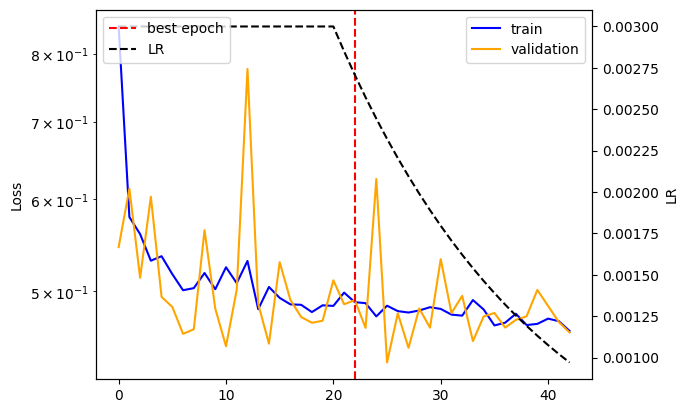

In [19]:
# plot delle curve di addestramento

f,ax = plt.subplots(1,1)
ax2 = ax.twinx()
ax.plot(train_curve,label="train",color="blue")
ax.plot(val_curve,label="validation",color="orange")
ax2.axvline(best_epoch,color="r",linestyle="--",label="best epoch")
ax.legend(loc=1)
ax.set_ylabel("Loss")


ax2.plot(lr_curve,"k--",label="LR",)
ax2.legend(loc=2)
plt.xlabel("Epochs")
ax2.set_ylabel("LR")
ax.set_yscale("log")

In [20]:
# carichiamo i pesi del best model
model=Net()
model.load_state_dict(torch.load('best_weights.pth', map_location=device))
model.to(device)
model.eval()


Net(
  (conv1): SAGEConv(3, 32, aggr=mean)
  (conv2): SAGEConv(32, 64, aggr=mean)
  (conv3): SAGEConv(64, 64, aggr=mean)
  (fc1): Linear(in_features=64, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=64, out_features=4, bias=True)
)

In [21]:
# calcolo e plot della matrice di confusione sul test set

from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

def test_model(model, test_loader):
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():
        for batch in test_loader:

            # Cambiamento rispetto alla CNN: il test loader restituisce Batch PyG, non tensori immagine.
            batch = batch.to(device)
            outputs = model(batch)
            targets = batch.y.detach().cpu().numpy()
            outputs = outputs.detach().cpu().numpy()

            predicted = np.argmax(outputs, 1)
            targets = np.argmax(targets , 1)

            y_true.extend(targets)
            y_pred.extend(predicted)

    cm = confusion_matrix(y_true, y_pred,normalize="true")

    return np.array(y_true), np.array(y_pred), cm


_,_,cm=test_model(model, test_loader)


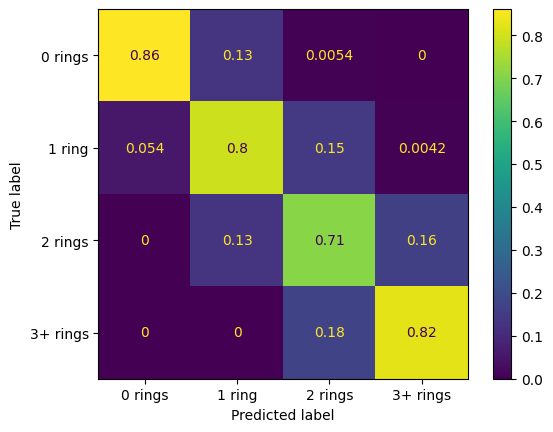

In [22]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0 rings", "1 ring", "2 rings", "3+ rings"])
disp.plot()
plt.show()